<a href="https://colab.research.google.com/github/brishti-c/Demand_Estimation/blob/main/Data_Analyst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Data Analysis

Load `air_fryers_clean_brand_year.csv`.

1. Verify that the data contain 10 brands and the years 2019-2023.

In [12]:
import pandas as pd

df = pd.read_csv("air_fryers_clean_brand_year.csv")

print(df.shape)
print(df.head())
print(df.groupby("year")["brand_share"].sum())
print(df["brand"].nunique())
print(df["year"].unique())

(50, 15)
     category  year       brand  purchase_count  product_count   avg_price  \
0  air_fryers  2019     chefman            1146             10   72.963695   
1  air_fryers  2019      cosori              11              2  159.990000   
2  air_fryers  2019   cuisinart            1616             22  229.465274   
3  air_fryers  2019        dash            3011             19   55.176333   
4  air_fryers  2019  gowise usa            4405             45   83.575551   

   avg_rating  compact_share  dual_basket_share  oven_style_share  \
0    4.434119       1.000000                0.0          0.780977   
1    4.581818       1.000000                0.0          0.090909   
2    4.481312       0.993812                0.0          0.889851   
3    4.390767       1.000000                0.0          0.973431   
4    4.552259       0.999773                0.0          0.129398   

   rotisserie_share  window_share  market_purchases  brand_share  \
0          0.243455      0.184119      

2. Plot the following over time by brand:
   - average price
   - average rating
   - brand market share

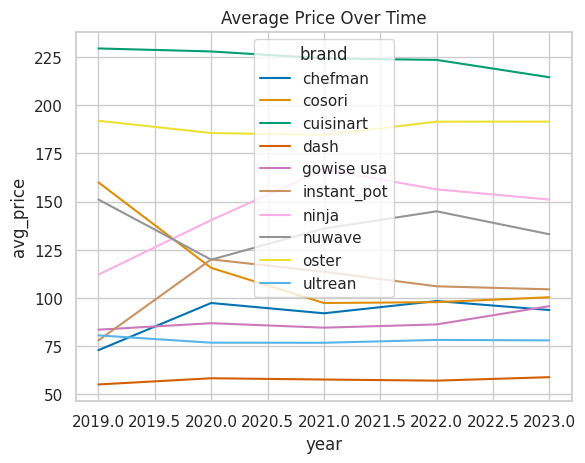

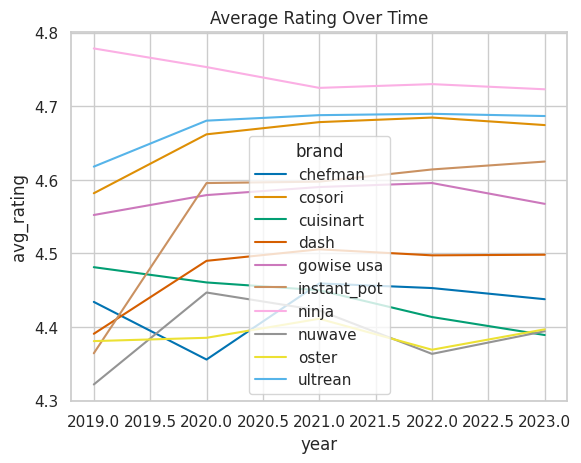

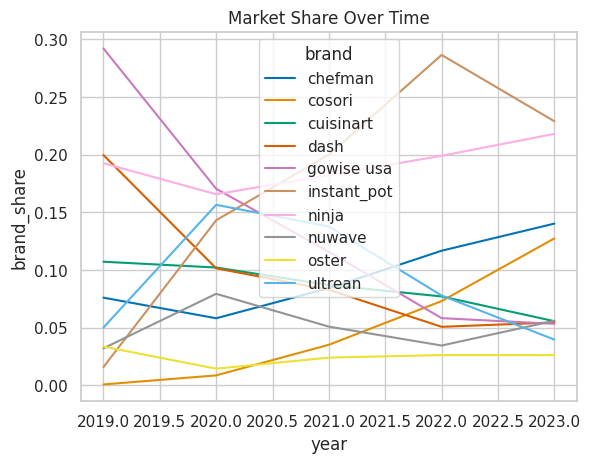

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=df, x="year", y="avg_price", hue="brand")
plt.title("Average Price Over Time")
plt.show()

sns.lineplot(data=df, x="year", y="avg_rating", hue="brand")
plt.title("Average Rating Over Time")
plt.show()

sns.lineplot(data=df, x="year", y="brand_share", hue="brand")
plt.title("Market Share Over Time")
plt.show()

3. Summarize the product characteristics:
   - Which features are common?
   - Which features are rare?
   - Are there brands that seem to specialize in different product types?

In [14]:
feature_cols = [
    "compact_share",
    "dual_basket_share",
    "oven_style_share",
    "rotisserie_share",
    "window_share"
]

df[feature_cols].mean().sort_values(ascending=False)
df.groupby("brand")[feature_cols].mean()

,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share
brand,,,,,
chefman,0.961595,0.013462,0.596962,0.370490,0.363081
cosori,0.996784,0.000000,0.029952,0.024076,0.000000
cuisinart,0.995902,0.000000,0.913059,0.000000,0.000000
dash,0.999481,0.000000,0.890098,0.000000,0.000000
gowise usa,0.999877,0.000000,0.183790,0.183569,0.001320
instant_pot,0.859655,0.000030,0.674784,0.102362,0.003012
ninja,0.992084,0.002488,0.100477,0.000000,0.000000
nuwave,0.995431,0.006622,0.542646,0.027123,0.000000
oster,1.000000,0.000000,0.864518,0.000000,0.000000


Based on the data, compact and oven style features are very common across nearly all brands, while dual basket, rotisserie, and window features are rare, with most brands showing zero or near-zero shares. Chefman stands out as the most diversified brand, offering meaningful shares of all five features, especially rotisserie and window, which are almost entirely absent from other brands like Cosori, Cuisinart, Dash, Oster, and Ultraen—these instead focus almost exclusively on compact and oven style products.

4. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?

The air fryer market from 2019–2023 consists of 10 brands with market shares correctly normalized within each year, and it appears moderately stable over time with a few dominant players maintaining larger shares. Brands like Dash and GoWISE USA have relatively high market shares, while others like Cosori initially have very small presence. Prices vary substantially across brands, with some (e.g., Cuisinart) positioned as more premium, while others compete on lower prices. Average ratings are consistently high across brands, suggesting strong overall consumer satisfaction. In terms of product characteristics, compact designs are nearly universal, while features like dual baskets and rotisserie functions are relatively rare, indicating niche offerings. There is also evidence of specialization, with some brands focusing more on oven-style or feature-rich products, while others emphasize simpler, compact models.

## 2. Demand Estimation

We will estimate a logit-style demand model using linear regression. The model is:

$$
\log(s_{bt}) = \alpha_0 + \alpha_t + \gamma_b + \beta_{price}p_{bt} + \beta_{rating}r_{bt} + \sum_{\ell=1}^L \beta_\ell x_{bt\ell} + \epsilon_{bt}.
$$

Here:

- $b$ indexes brands
- $t$ indexes years
- $s_{bt}$ is `brand_share`
- $p_{bt}$ is `avg_price`
- $r_{bt}$ is `avg_rating`
- $x_{bt\ell}$ are the product characteristics
- $\alpha_t$ are year dummy coefficients
- $\gamma_b$ are brand dummy coefficients
- $\beta_{price}$ is **one constant price coefficient**, shared by all brands and all years

That last point matters: do **not** estimate a different price coefficient for every brand-year. We do not have enough information for that, and it would make the cost calculation impossible to interpret.

Use `pd.get_dummies(..., drop_first=True)` for brand and year dummies. The dropped brand and dropped year become the reference categories, so all dummy coefficients are interpreted relative to those omitted categories.

Questions:

1. What is the estimated price coefficient, $\hat{\beta}_{price}$?
2. Is it negative? Why is that important?
3. Which product features are associated with higher demand?
4. Which brand dummy coefficients are largest? Remember that these are interpreted relative to the dropped brand.
5. Which year dummy coefficients are largest? Remember that these are interpreted relative to the dropped year.
6. What is the model's $R^2$?

This part of the work is the **data scientist** role: turning the cleaned data into a model that can be used for prediction and interpretation.

In [15]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='colorblind')

df = pd.read_csv('air_fryers_clean_brand_year.csv')
print(f'Shape: {df.shape}')
print(f'Brands: {sorted(df["brand"].unique())}')
print(f'Years:  {sorted(df["year"].unique())}')
df.head()

Shape: (50, 15)
Brands: ['chefman', 'cosori', 'cuisinart', 'dash', 'gowise usa', 'instant_pot', 'ninja', 'nuwave', 'oster', 'ultrean']
Years:  [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


In [16]:
feature_cols = [
    'compact_share', 'dual_basket_share', 'oven_style_share',
    'rotisserie_share', 'window_share'
]


brand_dummies = pd.get_dummies(df['brand'], drop_first=True, prefix='brand')
year_dummies  = pd.get_dummies(df['year'],  drop_first=True, prefix='year')


X = pd.concat([
    df[['avg_price', 'avg_rating'] + feature_cols],
    brand_dummies,
    year_dummies
], axis=1).astype(float)

y = df['log_brand_share'].values


X_const    = np.column_stack([np.ones(len(X)), X.values])
col_names  = ['const'] + X.columns.tolist()

print(f'Feature matrix shape: {X_const.shape}  (50 obs, {X_const.shape[1]} params)')
print('Reference brand: chefman | Reference year: 2019')

Feature matrix shape: (50, 21)  (50 obs, 21 params)
Reference brand: chefman | Reference year: 2019


In [17]:

coeffs, _, _, _ = np.linalg.lstsq(X_const, y, rcond=None)


y_pred = X_const @ coeffs
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2     = 1 - ss_res / ss_tot


n, p     = X_const.shape
sigma2   = ss_res / (n - p)
cov      = sigma2 * np.linalg.inv(X_const.T @ X_const)
se       = np.sqrt(np.diag(cov))
t_stats  = coeffs / se
p_vals   = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - p))

results = pd.DataFrame({
    'coef': coeffs,
    'std_err': se,
    't_stat': t_stats,
    'p_value': p_vals
}, index=col_names)

print(f'R² = {r2:.4f}   |   N = {n}   |   K = {p}')
results.round(4)

R² = 0.7635   |   N = 50   |   K = 21


,coef,std_err,t_stat,p_value
const,-13.3049,16.2831,-0.8171,0.4205
avg_price,-0.0377,0.0112,-3.3777,0.0021
avg_rating,0.2875,4.1520,0.0692,0.9453
compact_share,9.8153,3.6366,2.6991,0.0115
dual_basket_share,-9.5097,34.0299,-0.2795,0.7819
oven_style_share,1.9418,1.5056,1.2897,0.2074
rotisserie_share,-5.6741,4.3426,-1.3066,0.2016
window_share,12.8803,6.4673,1.9916,0.0559
brand_cosori,2.5519,2.2905,1.1141,0.2744
brand_cuisinart,6.4224,2.4649,2.6055,0.0143
